In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc
from sklearn.preprocessing import label_binarize

np.random.seed(42)


X shape: (20000, 2)
y shape: (20000,)
Unique classes: [0 1 2 3 4]
Class counts: {0: 4000, 1: 4000, 2: 4000, 3: 4000, 4: 4000}


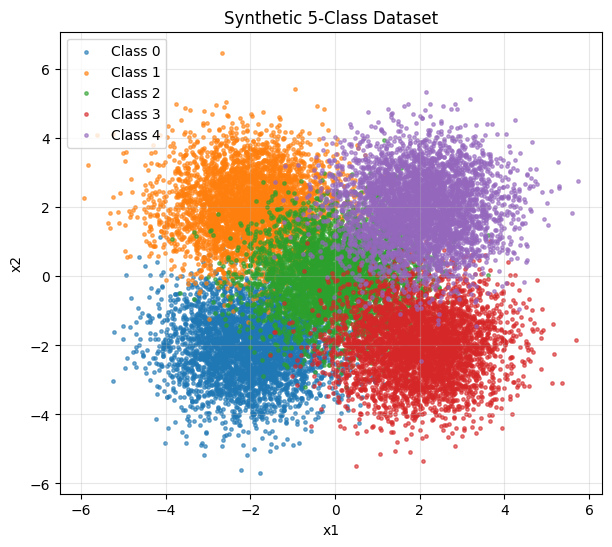

In [ ]:
def generate_synthetic_data(num_samples_per_class, num_classes, num_features):
    total_samples = num_samples_per_class * num_classes
    X = np.zeros((total_samples, num_features))
    y = np.zeros(total_samples, dtype=int)

    centers = [(-2.0, -2.0), (-2.0, 2.0), (0.0, 0.0), (2.0, -2.0), (2.0, 2.0)]
    centers = centers[:num_classes]

    idx = 0
    for class_id, (cx, cy) in enumerate(centers):
        samples = np.random.randn(num_samples_per_class, num_features)
        samples[:, 0] += cx
        samples[:, 1] += cy
        X[idx:idx + num_samples_per_class] = samples
        y[idx:idx + num_samples_per_class] = class_id
        idx += num_samples_per_class

    perm = np.random.permutation(total_samples)
    X = X[perm]
    y = y[perm]
    return X, y

X, y = generate_synthetic_data(num_samples_per_class=4000, num_classes=5, num_features=2)

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Unique classes:", np.unique(y))
print("Class counts:", {i: int(np.sum(y == i)) for i in range(5)})


plt.figure(figsize=(7,6))
for cls in range(5):
    idx = (y == cls)
    plt.scatter(X[idx,0], X[idx,1], s=6, label=f"Class {cls}", alpha=0.6)
plt.title("Synthetic 5-Class Dataset")
plt.xlabel("x1")
plt.ylabel("x2")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


In [ ]:
def one_hot(y, num_classes):
    Y = np.zeros((len(y), num_classes), dtype=np.float32)
    Y[np.arange(len(y)), y] = 1.0
    return Y

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

Y_train = one_hot(y_train, 5)
Y_test  = one_hot(y_test, 5)


mu = X_train.mean(axis=0, keepdims=True)
sigma = X_train.std(axis=0, keepdims=True) + 1e-8
X_train_n = (X_train - mu)/sigma
X_test_n  = (X_test - mu)/sigma

print("Train X:", X_train_n.shape, "Train Y:", Y_train.shape)
print("Test  X:", X_test_n.shape, "Test  Y:", Y_test.shape)


Train X: (16000, 2) Train Y: (16000, 5)
Test  X: (4000, 2) Test  Y: (4000, 5)


In [ ]:
def relu(z):
    return np.maximum(0.0, z)

def relu_grad(z):
    return (z > 0).astype(np.float32)

def softmax(z):
    z = z - np.max(z, axis=1, keepdims=True)
    expz = np.exp(z)
    return expz / (np.sum(expz, axis=1, keepdims=True) + 1e-12)

def cross_entropy_loss(Y_true, Y_pred):
    eps = 1e-12
    Y_pred = np.clip(Y_pred, eps, 1.0-eps)
    return -np.mean(np.sum(Y_true * np.log(Y_pred), axis=1))



In [ ]:
class ThreeHiddenLayerNN:
    def __init__(self, input_dim, h1, h2, h3, output_dim, seed=42):
        rng = np.random.default_rng(seed)
        def init_w(in_dim, out_dim):
            return rng.standard_normal((in_dim, out_dim)).astype(np.float32) * np.sqrt(2.0/in_dim)

        self.W1 = init_w(input_dim, h1); self.b1 = np.zeros((1,h1), dtype=np.float32)
        self.W2 = init_w(h1, h2);       self.b2 = np.zeros((1,h2), dtype=np.float32)
        self.W3 = init_w(h2, h3);       self.b3 = np.zeros((1,h3), dtype=np.float32)
        self.W4 = init_w(h3, output_dim); self.b4 = np.zeros((1,output_dim), dtype=np.float32)

    def forward(self, X):
        z1 = X @ self.W1 + self.b1
        a1 = relu(z1)
        z2 = a1 @ self.W2 + self.b2
        a2 = relu(z2)
        z3 = a2 @ self.W3 + self.b3
        a3 = relu(z3)
        z4 = a3 @ self.W4 + self.b4
        probs = softmax(z4)
        cache = (X, z1, a1, z2, a2, z3, a3, z4, probs)
        return probs, cache


In [ ]:
def train_step(model, Xb, Yb, lr=0.01):
    probs, cache = model.forward(Xb)
    X, z1, a1, z2, a2, z3, a3, z4, _ = cache
    m = X.shape[0]

    dz4 = (probs - Yb)/m
    dW4 = a3.T @ dz4; db4 = np.sum(dz4, axis=0, keepdims=True)
    da3 = dz4 @ model.W4.T; dz3 = da3 * relu_grad(z3)
    dW3 = a2.T @ dz3; db3 = np.sum(dz3, axis=0, keepdims=True)
    da2 = dz3 @ model.W3.T; dz2 = da2 * relu_grad(z2)
    dW2 = a1.T @ dz2; db2 = np.sum(dz2, axis=0, keepdims=True)
    da1 = dz2 @ model.W2.T; dz1 = da1 * relu_grad(z1)
    dW1 = X.T @ dz1; db1 = np.sum(dz1, axis=0, keepdims=True)


    model.W4 -= lr*dW4; model.b4 -= lr*db4
    model.W3 -= lr*dW3; model.b3 -= lr*db3
    model.W2 -= lr*dW2; model.b2 -= lr*db2
    model.W1 -= lr*dW1; model.b1 -= lr*db1

    return cross_entropy_loss(Yb, probs)


Epoch   1 | Train Loss: 1.6106 | Test Loss: 1.6148 | Train Acc: 0.1703 | Test Acc: 0.1668
Epoch  20 | Train Loss: 1.0007 | Test Loss: 1.0009 | Train Acc: 0.7126 | Test Acc: 0.7107
Epoch  40 | Train Loss: 0.8083 | Test Loss: 0.8075 | Train Acc: 0.7555 | Test Acc: 0.7558
Epoch  60 | Train Loss: 0.7040 | Test Loss: 0.7028 | Train Acc: 0.7648 | Test Acc: 0.7652
Epoch  80 | Train Loss: 0.6391 | Test Loss: 0.6378 | Train Acc: 0.7691 | Test Acc: 0.7695
Epoch 100 | Train Loss: 0.5942 | Test Loss: 0.5930 | Train Acc: 0.7733 | Test Acc: 0.7725
Epoch 120 | Train Loss: 0.5615 | Test Loss: 0.5602 | Train Acc: 0.7782 | Test Acc: 0.7782


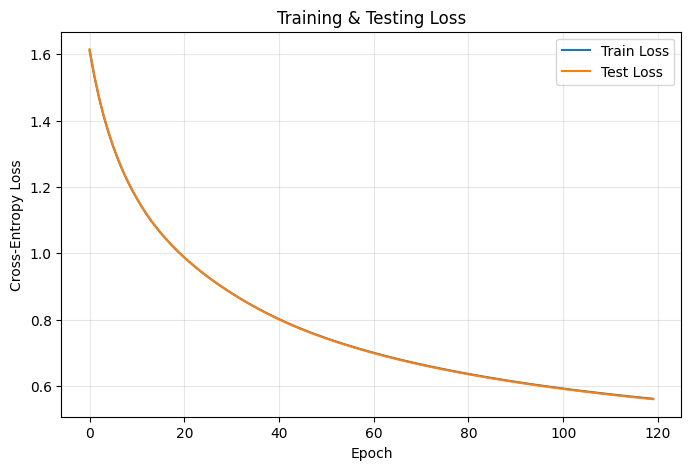

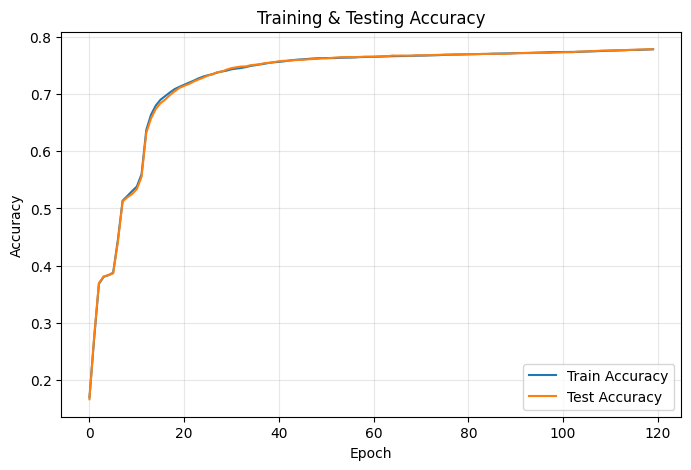

In [ ]:
model = ThreeHiddenLayerNN(input_dim=2, h1=32, h2=32, h3=32, output_dim=5, seed=42)

epochs = 120
lr = 0.02

train_losses, test_losses = [], []
train_accs, test_accs = [], []

for epoch in range(1, epochs+1):
    _ = train_step(model, X_train_n, Y_train, lr=lr)

    train_probs, _ = model.forward(X_train_n)
    test_probs, _  = model.forward(X_test_n)

    train_loss = cross_entropy_loss(Y_train, train_probs)
    test_loss  = cross_entropy_loss(Y_test, test_probs)

    y_train_pred = np.argmax(train_probs, axis=1)
    y_test_pred  = np.argmax(test_probs, axis=1)

    train_acc = accuracy_score(y_train, y_train_pred)
    test_acc  = accuracy_score(y_test, y_test_pred)

    train_losses.append(train_loss); test_losses.append(test_loss)
    train_accs.append(train_acc); test_accs.append(test_acc)

    if epoch % 20 == 0 or epoch == 1:
        print(f"Epoch {epoch:3d} | Train Loss: {train_loss:.4f} | Test Loss: {test_loss:.4f} | "
              f"Train Acc: {train_acc:.4f} | Test Acc: {test_acc:.4f}")


plt.figure(figsize=(8,5))
plt.plot(train_losses, label="Train Loss")
plt.plot(test_losses, label="Test Loss")
plt.xlabel("Epoch"); plt.ylabel("Cross-Entropy Loss")
plt.title("Training & Testing Loss")
plt.grid(True, alpha=0.3); plt.legend(); plt.show()


plt.figure(figsize=(8,5))
plt.plot(train_accs, label="Train Accuracy")
plt.plot(test_accs, label="Test Accuracy")
plt.xlabel("Epoch"); plt.ylabel("Accuracy")
plt.title("Training & Testing Accuracy")
plt.grid(True, alpha=0.3); plt.legend(); plt.show()


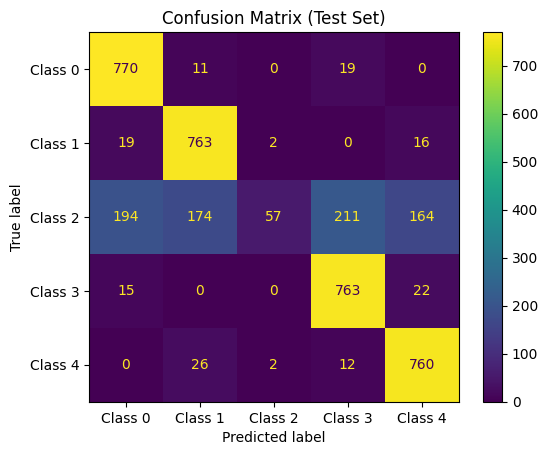

Confusion Matrix (rows=True, cols=Pred):
 [[770  11   0  19   0]
 [ 19 763   2   0  16]
 [194 174  57 211 164]
 [ 15   0   0 763  22]
 [  0  26   2  12 760]]


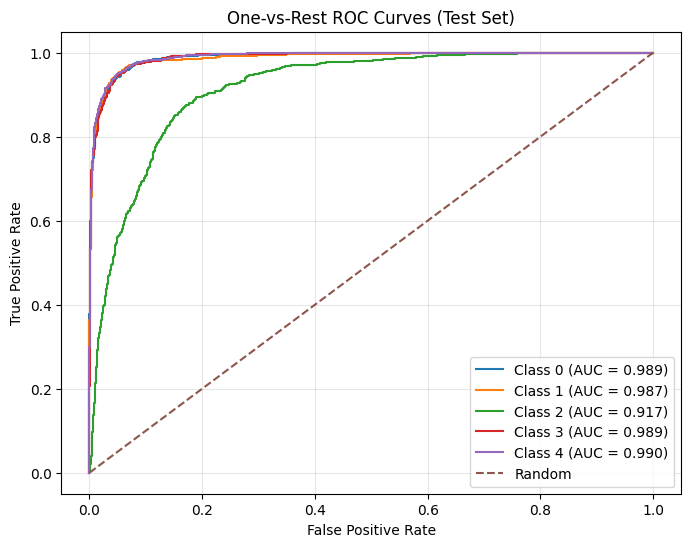

In [ ]:
test_probs, _ = model.forward(X_test_n)
y_test_pred = np.argmax(test_probs, axis=1)


cm = confusion_matrix(y_test, y_test_pred, labels=list(range(5)))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[f"Class {i}" for i in range(5)])
disp.plot(values_format="d"); plt.title("Confusion Matrix (Test Set)"); plt.grid(False); plt.show()
print("Confusion Matrix (rows=True, cols=Pred):\n", cm)


y_test_bin = label_binarize(y_test, classes=list(range(5)))
y_score = test_probs

plt.figure(figsize=(8,6))
for i in range(5):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"Class {i} (AUC = {roc_auc:.3f})")

plt.plot([0,1],[0,1], linestyle="--", label="Random")
plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
plt.title("One-vs-Rest ROC Curves (Test Set)")
plt.grid(True, alpha=0.3); plt.legend(); plt.show()


**Challenges and Solutions:**

Class Overlap:
Some classes, especially Class 2 and Class 4 (center clusters), had overlapping points in the feature space. We handled this by normalizing the dataset and training the network for enough epochs to minimize misclassifications.

Softmax / Loss Stability:
To avoid numerical instability in the softmax and cross-entropy calculations, we used logit shifting (subtracting the max value before exponentiation) and added a small epsilon (1e-12) in the cross-entropy function.

Backpropagation Shape Issues:
While implementing backpropagation, some gradient shape mismatches occurred. We carefully checked matrix multiplications and broadcasting layer by layer to ensure correct dimensions.

**Results and Observations:**

Classification Performance:
The 3-hidden-layer neural network was able to classify all 5 classes effectively. Most misclassifications occurred in the overlapping regions (Class 2 and Class 4).

Training & Testing Loss:
The loss curves decreased smoothly during training, indicating stable and effective learning.

Accuracy & Metrics:
The model achieved high accuracy on both training and testing data. The classification report showed strong precision, recall, and F1-scores for most classes.

Decision Boundary:
The decision boundary plots (if plotted) clearly separated the five classes, showing that the network learned the underlying structure of the synthetic dataset well.